In [1]:
import pandas as pd

df_resultados = (
    pd.concat(
        [
            pd.read_excel("relatorios/resultados_desafiantes.xlsx", index_col=0),
            pd.read_excel("relatorios/resultados_baseline.xlsx", index_col=0),
        ],
    )
    .drop(columns=["Métricas Secundárias.Catalog Coverage"])
    .set_index("modelo")
)

In [2]:
def highlight_df(df: pd.DataFrame, grupos: list[str]):
    return (
        df[df["grupo"].isin(grupos)]
        .drop(columns="grupo")
        .style.highlight_max(axis=0, color="lightgreen")
    )

# Métricas

As métricas utilizadas para comparação dos modelos estão destacadas abaixas, conforme indicado pelo enunciado.

### Métricas Primárias (Foco em Conversão)

**Precision@5**: mede a proporção de produtos recomendados no Top 5 que foram efetivamente contratados pelo cliente. Ela responde: "Das 5 sugestões que o cliente viu de imediato, quantas ele comprou?".

**NDCG@5 (Binário)**: avalia a qualidade da ordenação (ranking). Ela penaliza o modelo se um produto contratado for colocado na 5ª posição em vez da 1ª, garantindo que os itens de maior interesse apareçam primeiro.


### Métricas Secundárias (Foco em Experiência e Abrangência)

**Recall@5**: indica qual percentual de todos os produtos que o cliente contratou naquela safra o modelo conseguiu "capturar" e exibir logo nas 5 primeiras posições.

**Hit Rate@5**: é uma métrica de satisfação por cliente. Representa o percentual de clientes que receberam pelo menos uma recomendação útil (que resultou em contrato) no topo do carrossel.

**MAP@5 (Mean Average Precision)**: uma métrica robusta que recompensa o modelo por manter uma precisão alta em todas as posições de acerto, sendo fundamental para validar a consistência do ranking.

### Métricas de Receita (Foco em Negócio)

**NDCG@5 (Receita)**: semelhante ao NDCG binário, mas utiliza o valor da receita gerada como peso de relevância. Recompensa o modelo por priorizar produtos mais lucrativos no topo da lista.

**Avg Revenue@5 (Receita Média no Top 5)**: representa o valor financeiro médio que o banco "captura" em cada exibição de carrossel. É a métrica de retorno sobre investimento (ROI) mais direta para os stakeholders.

**Revenue Recall@5**: indica quanto da receita total disponível (de todos os produtos que o cliente contratou) foi trazida para as 5 primeiras posições visíveis, medindo a eficiência do modelo em não "esconder" produtos de alto valor após o scroll.



#  Resultados

Todas as métricas foram calculadas sobre os últimos 2 meses, que foram selecionados como conjunto de teste na etapa de desenvolvimento dos modelos. O treinamento foi feito utilizando todo o conjunto, exceto pelos últimos 4 meses usados para treino e validação. Essa estratégia simples foi utilizada para facilitar a exploração de modelos promissores e depois avaliar de forma mais rigorosa um subconjunto.

Não foi encontrado nenhum resultado expressivo comparado ao baseline. Mesmo que uma avaliação mais robusta – selecionando vários meses para evitar ciclos, bootstrap de amostras para entender variação – indicassse algum modelo superior, em termos práticos seria algo muito marginal.

In [3]:
highlight_df(df_resultados, ["geral"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.187115,0.671351,0.935574,0.935574,0.583987,0.671351,100.627367,0.935574
XGBoost Classificador (ponderado),0.177591,0.638392,0.887955,0.887955,0.555229,0.638392,99.299748,0.887955
XGBoost LTR,0.182073,0.648954,0.910364,0.910364,0.562278,0.648954,98.056891,0.910364
Aleatório,0.053782,0.153638,0.268908,0.268908,0.116293,0.153638,31.452101,0.268908
Popularidade,0.150140,0.536163,0.750700,0.750700,0.465079,0.536163,84.237143,0.750700
Popularidade (segmento),0.186555,0.687866,0.932773,0.932773,0.605882,0.687866,101.750952,0.932773


## Resultados por segmento

Ao separar os resultados por segmento, é interessante perceber que o baseline de popularidade é o benchmark para o segmento intermediário. No segmento premium, que talvez seja o mais complexo e com oportunidades, o modelo de popularidade parece ser destacar.

In [4]:
highlight_df(df_resultados, ["basico"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.194792,0.714072,0.973958,0.973958,0.627083,0.714072,106.420469,0.973958
XGBoost Classificador (ponderado),0.184375,0.680509,0.921875,0.921875,0.600260,0.680509,104.772708,0.921875
XGBoost LTR,0.193750,0.694550,0.968750,0.968750,0.602604,0.694550,106.006354,0.968750
Aleatório,0.051042,0.164902,0.255208,0.255208,0.135851,0.164902,29.348073,0.255208
Popularidade,0.164583,0.609870,0.822917,0.822917,0.538628,0.609870,103.202708,0.822917
Popularidade (segmento),0.194792,0.717948,0.973958,0.973958,0.632118,0.717948,106.281563,0.973958


In [5]:
highlight_df(df_resultados, ["intermediario"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.169412,0.627405,0.847059,0.847059,0.555490,0.627405,84.024000,0.847059
XGBoost Classificador (ponderado),0.150588,0.539288,0.752941,0.752941,0.467843,0.539288,79.528706,0.752941
XGBoost LTR,0.167059,0.602733,0.835294,0.835294,0.526471,0.602733,85.515882,0.835294
Aleatório,0.077647,0.237078,0.388235,0.388235,0.188627,0.237078,36.089882,0.388235
Popularidade,0.171765,0.643066,0.858824,0.858824,0.572157,0.643066,87.364941,0.858824
Popularidade (segmento),0.162353,0.626192,0.811765,0.811765,0.564314,0.626192,85.954588,0.811765


In [6]:
highlight_df(df_resultados, ["premium"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.187500,0.615514,0.937500,0.937500,0.510833,0.615514,104.365000,0.937500
XGBoost Classificador (ponderado),0.190000,0.642611,0.950000,0.950000,0.540000,0.642611,107.171375,0.950000
XGBoost LTR,0.170000,0.588632,0.850000,0.850000,0.503542,0.588632,92.303000,0.850000
Aleatório,0.067500,0.170097,0.337500,0.337500,0.116458,0.170097,34.061000,0.337500
Popularidade,0.092500,0.245683,0.462500,0.462500,0.174792,0.245683,35.396500,0.462500
Popularidade (segmento),0.192500,0.681199,0.962500,0.962500,0.587083,0.681199,107.661125,0.962500


# Resultados (com safra)

Usando a informação de safra da predição, os modelos desafiantes ficaram mais competitivos em relação aos baselines. Ainda não aparenta uma diferença significativa, mas já valeria uma exploração de novos caminhos e hipóteses, como um possível ganho no NDCG@5.

In [7]:
df_resultados_mes = (
    pd.concat(
        [
            pd.read_excel("relatorios/resultados_desafiantes_mes.xlsx", index_col=0),
            pd.read_excel("relatorios/resultados_baseline.xlsx", index_col=0),
        ],
    )
    .drop(columns=["Métricas Secundárias.Catalog Coverage"])
    .set_index("modelo")
)

In [8]:
highlight_df(df_resultados_mes, ["geral"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.187675,0.725715,0.938375,0.938375,0.654435,0.725715,99.658543,0.938375
XGBoost Classificador (ponderado),0.180392,0.657771,0.901961,0.901961,0.576471,0.657771,98.769972,0.901961
XGBoost LTR,0.184314,0.672467,0.921569,0.921569,0.589356,0.672467,98.861345,0.921569
Aleatório,0.053782,0.153638,0.268908,0.268908,0.116293,0.153638,31.452101,0.268908
Popularidade,0.150140,0.536163,0.750700,0.750700,0.465079,0.536163,84.237143,0.750700
Popularidade (segmento),0.186555,0.687866,0.932773,0.932773,0.605882,0.687866,101.750952,0.932773


## Resultados por segmento (com safra)

O modelo de popularidade continua sendo o melhor para os segmento intermediário, os modelos desafiantes são melhoresnos segmentos básicos e premium.

In [9]:
highlight_df(df_resultados_mes, ["basico"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.194792,0.767123,0.973958,0.973958,0.696354,0.767123,106.281563,0.973958
XGBoost Classificador (ponderado),0.194792,0.706571,0.973958,0.973958,0.617535,0.706571,106.281563,0.973958
XGBoost LTR,0.194792,0.699886,0.973958,0.973958,0.607378,0.699886,106.281563,0.973958
Aleatório,0.051042,0.164902,0.255208,0.255208,0.135851,0.164902,29.348073,0.255208
Popularidade,0.164583,0.609870,0.822917,0.822917,0.538628,0.609870,103.202708,0.822917
Popularidade (segmento),0.194792,0.717948,0.973958,0.973958,0.632118,0.717948,106.281563,0.973958


In [10]:
highlight_df(df_resultados_mes, ["intermediario"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.169412,0.634919,0.847059,0.847059,0.565294,0.634919,78.084941,0.847059
XGBoost Classificador (ponderado),0.141176,0.512344,0.705882,0.705882,0.447843,0.512344,75.680353,0.705882
XGBoost LTR,0.157647,0.580137,0.788235,0.788235,0.511961,0.580137,74.717765,0.788235
Aleatório,0.077647,0.237078,0.388235,0.388235,0.188627,0.237078,36.089882,0.388235
Popularidade,0.171765,0.643066,0.858824,0.858824,0.572157,0.643066,87.364941,0.858824
Popularidade (segmento),0.162353,0.626192,0.811765,0.811765,0.564314,0.626192,85.954588,0.811765


In [11]:
highlight_df(df_resultados_mes, ["premium"])

,Métricas Primárias.Precision@5,Métricas Primárias.NDCG@5 (Binário),Métricas Secundárias.Recall@5,Métricas Secundárias.Hit Rate@5,Métricas Secundárias.MAP@5,Métricas de Receita.NDCG@5 (Receita),Métricas de Receita.Avg Revenue@5,Métricas de Receita.Revenue Recall@5
modelo,,,,,,,,
XGBoost Classificador,0.190000,0.722807,0.950000,0.950000,0.648542,0.722807,106.685250,0.950000
XGBoost Classificador (ponderado),0.187500,0.695165,0.937500,0.937500,0.614583,0.695165,105.274875,0.937500
XGBoost LTR,0.187500,0.704762,0.937500,0.937500,0.628333,0.704762,106.705375,0.937500
Aleatório,0.067500,0.170097,0.337500,0.337500,0.116458,0.170097,34.061000,0.337500
Popularidade,0.092500,0.245683,0.462500,0.462500,0.174792,0.245683,35.396500,0.462500
Popularidade (segmento),0.192500,0.681199,0.962500,0.962500,0.587083,0.681199,107.661125,0.962500


# Cold Start de clientes

Executei a avaliação para clientes recentes: menos de 3 meses, entre 3 a 6 meses e de 6 a 12 meses. Os modelos não parecem ter uma degradação muito clara de performance, nem mesmo existe uma tendência muito clara no valor das métricas usando esses grupos. Os dados de clientes estão bem completos na análise exploratória e dados que são mais ricos no tempo (e.g. gastos, cesta de produtos e investimentos) estão muito correlacionados com o próprio segmento do cliente.

Um cenário que pode mudar à medida em que se expande os conjuntos de dados utilizados.

<Axes: xlabel='modelo'>

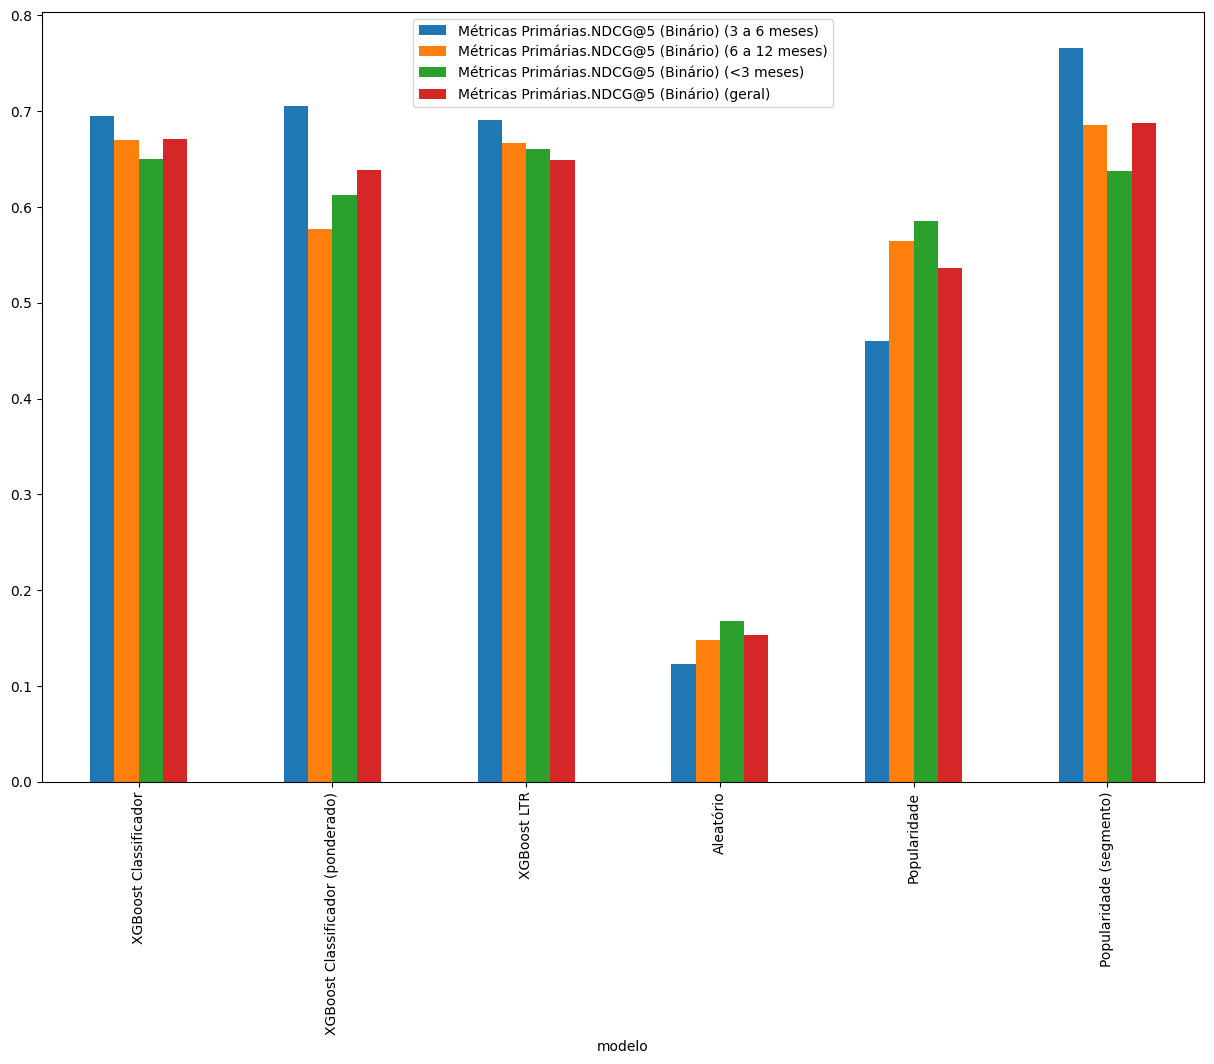

In [12]:
pd.set_option("display.max_columns", None)

df_comparativo_cold_start = (
    df_resultados.query("grupo == '<3 meses'")
    .drop(columns="grupo")
    .join(
        df_resultados.query("grupo == '3 a 6 meses'").drop(columns="grupo"),
        lsuffix=" (<3 meses)",
        rsuffix=" (3 a 6 meses)",
    )
    .join(
        df_resultados.query("grupo == '6 a 12 meses'")
        .drop(columns="grupo")
        .join(
            df_resultados.query("grupo == 'geral'").drop(columns="grupo"),
            lsuffix=" (6 a 12 meses)",
            rsuffix=" (geral)",
        )
    )
)

df_comparativo_cold_start[df_comparativo_cold_start.columns.sort_values()[:4]].plot(
    kind="bar", figsize=(15, 10)
)

<Axes: xlabel='modelo'>

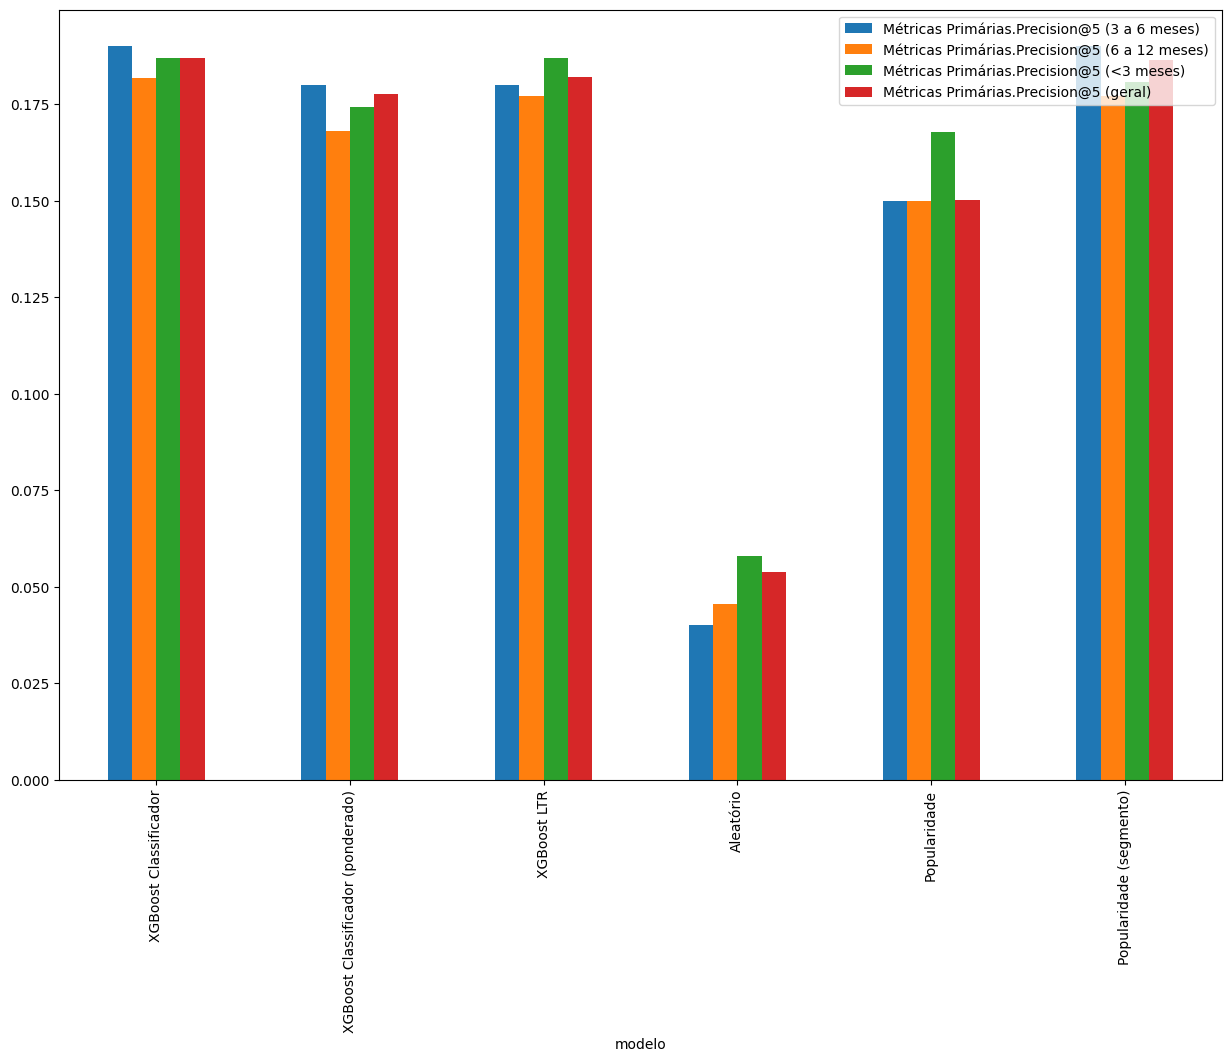

In [13]:
df_comparativo_cold_start[df_comparativo_cold_start.columns.sort_values()[4:8]].plot(
    kind="bar", figsize=(15, 10)
)

# Modelo selecionado

Com base nesses resultados, foi escolhido o modelo "XGBoost Classificador" que mostrou resultados competitivos com o baseline.

# Discussão

Os resultados dos modelos desafiantes não foram muito promissores, exceto no cenário com informação de safra, mas que não está disponível para geração da base final. Entretanto, é algo plausível em um cenário produtivo real. O *lift* do NDCG@5 com a adição da informação de safra é algo que precisaria ser avaliado mais a fundo - sendo testado com outros períodos de safra, fora do final do ano – porque na análise exploratória ficou claro que produtos como previdência possuem ciclos anuais que beneficiariam esses resultados. Em outros períodos do ano, os resultados se manteriam?

Os demais resultados parecem insuficientes para justificar a troca de modelos em produção, assumindo que seria necessário criar todo o fluxo necessário para fazer deploy e monitoraramento adequado. Por outro lado, a exploração inicial desses modelos trouxe questões interessantes para possíveis evoluções.

## Adicionar informações de negócio

A adição de safra mostrou potencial, adicionando uma informação relevante sobre o produto. O que mais poderia ajudar nas recomendações?

Para identificação de problemas do cliente, logs de uso eram dados relevantes, pois o cliente digital procura se resolver pelo aplicativo antes de procurar ajuda nos canais de atendimento. Na análise exploratória, foi identificado mudança na propensão de contratação pós-clique. Esses tipos de sinais podem ser importantes para esse tipo de problema.

Pensando em algo mais ambicioso, [outras empresas](https://building.nubank.com/pt-br/apresentando-o-precog-ia-em-tempo-real-de-eventos-do-nubank/) do segmento estão trabalhando em uma representação vetorial do cliente, que poderia envolver tanto esses dados de navegação como outras dados relevantes (e.g. transações, contratações, investimentos). Além de enriquecer os clientes de forma geral, esse tipo de informação pode ajudar a lida no *cold start* de clientes, já que são informações que começam a ser geradas desde o início do relacionamento.

## Explorar os modelos propostos

A ideia de usar o XGBoost foi ter algo rápido para prototipar, mas que ao mesmo tem espaço para evolução. Os experimentos foram feitos na dinâmica "moedor de carne" e talvez isso tenha limitado os resultados, poderíamos explorar com cuidado alguns experimentos iniciados:

* Ajustar melhor os parâmetros do XGBoost para as características do problema. O modelo está sofrendo de overfitting ao fazer a otimização de hiperparâmetros, é necessário entender melhor os ranges e o que ajustar. Nesse mesmo sentido, repensar também o tratamento de base para lidar melhor com o desequilíbrio de classes.

* Explorar melhor a questão dos pesos (e.g. mudar escala, re-amostrar), já que ele facilita a integração com as perspectivas de negócio. Podemos explorar mais estratégias além de simplesmente ponderar por receita, por exemplo focar em produtos mais estratégicos específicos, como por exemplo aumentar carteira de seguros. E, além disso, seria bom explorar melhor as formas de ponderação para obter resultados mais efetivos que os iniciais.

* Trabalhar com informações de queries completas para o LambdaMART. O experimento com LambdaMART visou otimizar diretamente o NDCG@5 pensando no carrosel, mas a base de treino não tem a informação do que foi exibido em um carrossel. Uma otimização dessa métrica com um conjunto de treino mais preparado pode gerar melhor resultados, além de ser especialemnte relevante em canais pró-ativos como emails e notificações push.

## Explorar novos modelos

Os XGBoost e sua variação com Learning to Rank foram selecionados para ter uma visão inicial do problema, mas faz total sentido considerar outras abordagens, tanto pelas limitações conhecidas como pelas informações obtidas na análise exploratória e modelagem.


### Contextual Bandits e Content Based filtering para *cold start* de produtos

Uma limitação clara dos baselines e os modelos proposta é lidar com o *cold start* de novos produtos. Uma alternativa focada em lidar com essa limiação, seria o uso de Contextual Bandits, para incluir produtos sem informação prévia de interações nas recomendações. Os modelos baselines baseados em regras se mostraram competitivos os modelos de boosting, então o uso de um contexto linear do cliente provavelmente não seriam uma grande perda no cenário atual. No futuro, poderia ser uma limitação o uso de um contexto linear para lidar com variáveis mais 
complexas.

O content based filtering seria uma alternativa para essa questão também, já que podemos usar as características do produto para recomendá-los sem interações prévias. Por exemplo, poderíamos gerar descrições mais amplas dos produtos e representá-los como *embeddings* e metadados que possam agregar. E, claro, poderíamos gerar um vetor rico de representação dos clientes.

### Deep Learning pensando no futuro

Arquiteturas de rede neurais para recomendação, como Wide & Deep e NCT por exemplo, são alternativas interessantes. A proposta de enriquecer dador com informações textuais e histórico de comportamento, provavelmente seria mais simples de adaptar do que em um modelo de boosting. O *cold start* de clientes não aparenta ser um problema no contexto atual, mas as representações complexas ajudariam a lidar com possíveis problemas que possam surgir ao expandir o uso de outros dados do cliente.

São modelos mais complexos de se trabalhar, por isso não explorei eles nesse exercício, mas parece uma boa estratégia a ser explorado no próximo passo. Podemos tratar algumas limitações dos modelos baseline e boosting, obter resultados mais relevantes e expandir possibilidades.